<a href="https://colab.research.google.com/github/ian-shade/Autotrader-Cars-Price-Predictions-ML/blob/main/aml_coursework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Advanced Machine Learning Coursework

In [3]:
# ============================================================
# Imports & Configuration
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Scikit-learn — preprocessing
from sklearn.model_selection import (
    train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV, KFold
)
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder, PolynomialFeatures
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

# Scikit-learn — feature selection
from sklearn.feature_selection import (
    SelectKBest, f_regression, mutual_info_regression, RFE, SequentialFeatureSelector
)

# Scikit-learn — models
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor, GradientBoostingRegressor,
    BaggingRegressor, VotingRegressor, StackingRegressor,
    AdaBoostRegressor, ExtraTreesRegressor
)
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

# Scikit-learn — dimensionality reduction & clustering
from sklearn.decomposition import PCA, KernelPCA
from sklearn.manifold import TSNE, MDS, Isomap
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering

# Scikit-learn — metrics
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    silhouette_score
)

# Boosting libraries
import xgboost as xgb
import lightgbm as lgb

# Explainability
import shap

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------
SEED = 42
np.random.seed(SEED)

# ------------------------------------------------------------
# Plot settings — clean, publication-quality
# ------------------------------------------------------------
%matplotlib inline

plt.rcParams.update({
    "figure.figsize": (10, 6),
    "figure.dpi": 150,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "font.family": "serif",
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.1,
})
sns.set_style("whitegrid")
sns.set_palette("muted")

print("All imports loaded successfully.")
print(f"Random seed: {SEED}")

All imports loaded successfully.
Random seed: 42


In [4]:
# ============================================================
# Google Drive Mount (Colab)
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

# ============================================================
# Load Dataset
# ============================================================

DATA_PATH = "/content/drive/MyDrive/Colab/adverts.csv"

df = pd.read_csv(DATA_PATH)

print(f"Shape: {df.shape}")
print(f"\n{'='*60}")
print("Data Types:")
print(f"{'='*60}")
print(df.dtypes)
print(f"\n{'='*60}")
print("First 5 Rows:")
print(f"{'='*60}")
df.head()

Mounted at /content/drive
Shape: (402005, 12)

Data Types:
public_reference           int64
mileage                  float64
reg_code                  object
standard_colour           object
standard_make             object
standard_model            object
vehicle_condition         object
year_of_registration     float64
price                      int64
body_type                 object
crossover_car_and_van       bool
fuel_type                 object
dtype: object

First 5 Rows:


,public_reference,mileage,reg_code,standard_colour,standard_make,standard_model,vehicle_condition,year_of_registration,price,body_type,crossover_car_and_van,fuel_type
0,202006039777689,0.0,NaN,Grey,Volvo,XC90,NEW,NaN,73970,SUV,False,Petrol Plug-in Hybrid
1,202007020778260,108230.0,61,Blue,Jaguar,XF,USED,2011.0,7000,Saloon,False,Diesel
2,202007020778474,7800.0,17,Grey,SKODA,Yeti,USED,2017.0,14000,SUV,False,Petrol
3,202007080986776,45000.0,16,Brown,Vauxhall,Mokka,USED,2016.0,7995,Hatchback,False,Diesel
4,202007161321269,64000.0,64,Grey,Land Rover,Range Rover Sport,USED,2015.0,26995,SUV,False,Diesel


In [5]:
df.describe()

,public_reference,mileage,year_of_registration,price
count,4.020050e+05,401878.000000,368694.000000,4.020050e+05
mean,2.020071e+14,37743.595656,2015.006206,1.734197e+04
std,1.691662e+10,34831.724018,7.962667,4.643746e+04
min,2.013072e+14,0.000000,999.000000,1.200000e+02
25%,2.020090e+14,10481.000000,2013.000000,7.495000e+03
50%,2.020093e+14,28629.500000,2016.000000,1.260000e+04
75%,2.020102e+14,56875.750000,2018.000000,2.000000e+04
max,2.020110e+14,999999.000000,2020.000000,9.999999e+06


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 402005 entries, 0 to 402004
Data columns (total 12 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   public_reference       402005 non-null  int64  
 1   mileage                401878 non-null  float64
 2   reg_code               370148 non-null  object 
 3   standard_colour        396627 non-null  object 
 4   standard_make          402005 non-null  object 
 5   standard_model         402005 non-null  object 
 6   vehicle_condition      402005 non-null  object 
 7   year_of_registration   368694 non-null  float64
 8   price                  402005 non-null  int64  
 9   body_type              401168 non-null  object 
 10  crossover_car_and_van  402005 non-null  bool   
 11  fuel_type              401404 non-null  object 
dtypes: bool(1), float64(2), int64(2), object(7)
memory usage: 34.1+ MB


---
## 1. Data Description and Pre-Processing

### 1.1 Missing Values

We first examine missingness across all columns to decide on imputation or removal strategies. Columns with a very high proportion of missing values may need to be dropped entirely, while moderate missingness can be addressed with imputation.

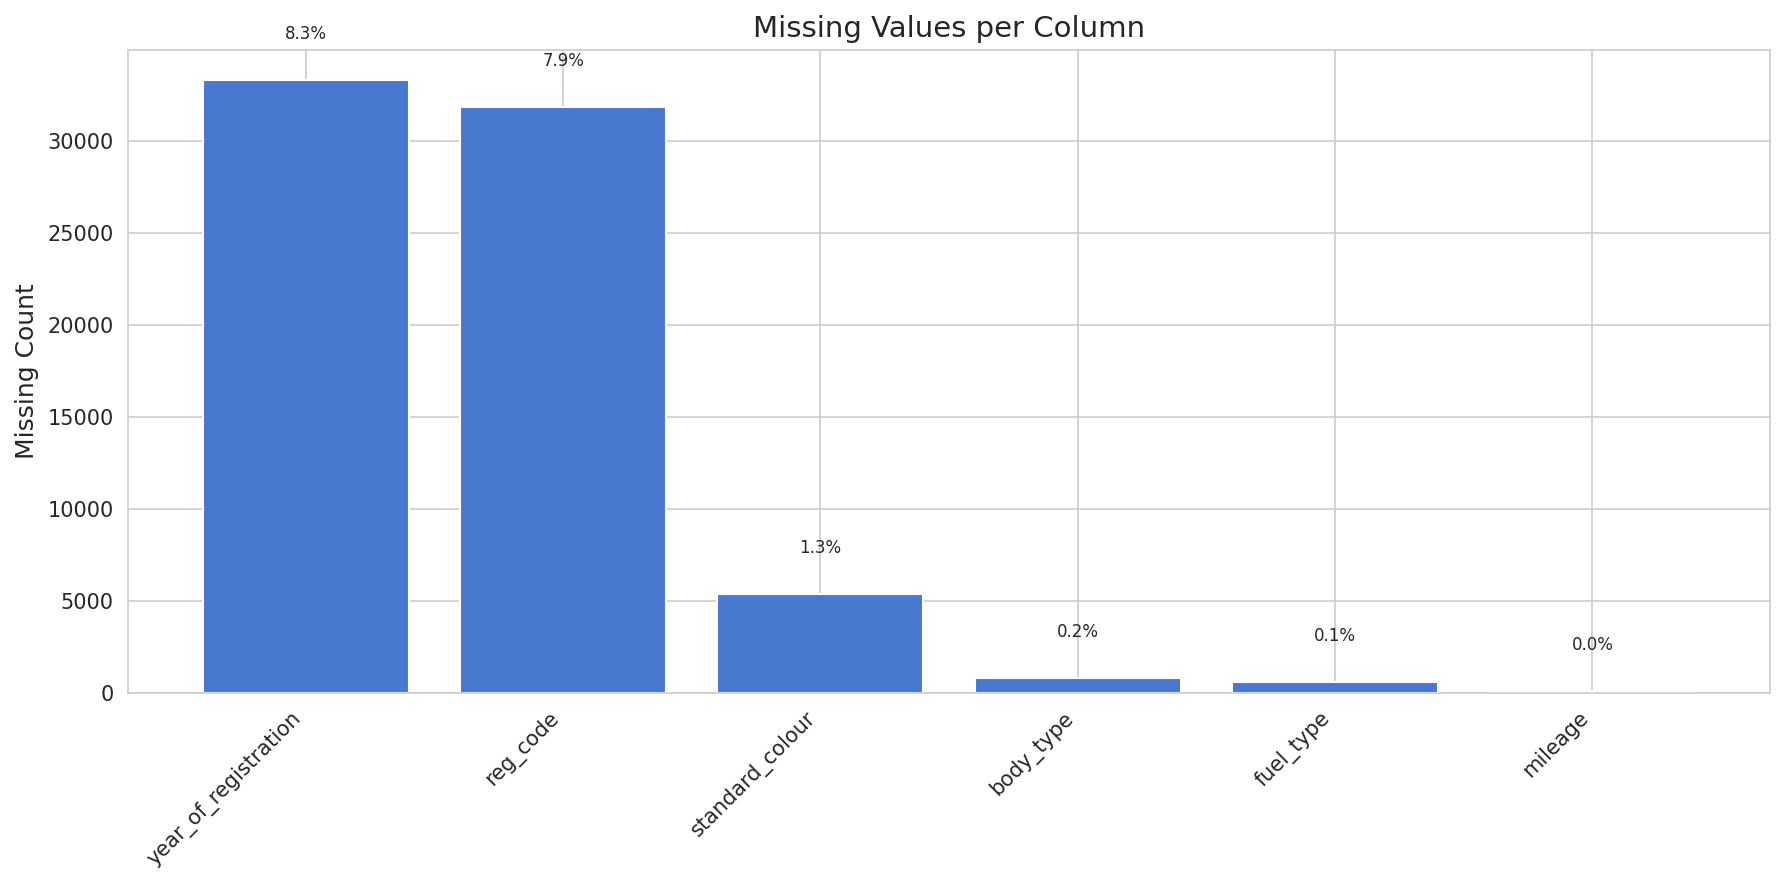


Total rows: 402,005
Columns with missing values: 6 / 12
                      missing_count   pct
year_of_registration          33311  8.29
reg_code                      31857  7.92
standard_colour                5378  1.34
body_type                       837  0.21
fuel_type                       601  0.15
mileage                         127  0.03


In [7]:
# ------------------------------------------------------------
# 1.1  Missing values per column (sorted bar chart)
# ------------------------------------------------------------
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(range(len(missing)), missing.values, color=sns.color_palette("muted")[0])
ax.set_xticks(range(len(missing)))
ax.set_xticklabels(missing.index, rotation=45, ha="right")
ax.set_ylabel("Missing Count")
ax.set_title("Missing Values per Column")

# Annotate each bar with the percentage missing
for i, (count, col) in enumerate(zip(missing.values, missing.index)):
    pct = count / len(df) * 100
    ax.text(i, count + len(df) * 0.005, f"{pct:.1f}%", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
# fig.savefig("figures/missing_values.png")
plt.show()

print(f"\nTotal rows: {len(df):,}")
print(f"Columns with missing values: {len(missing)} / {df.shape[1]}")
print(missing.to_frame("missing_count").assign(
    pct=lambda x: (x["missing_count"] / len(df) * 100).round(2)
))

### 1.2 Target Variable Distribution

Car prices typically follow a right-skewed distribution — most adverts cluster at lower prices with a long tail of luxury and specialist vehicles. A log-scale view helps reveal the underlying structure more clearly and will inform whether a log-transform of the target is beneficial for modelling.

Using target column: 'price'


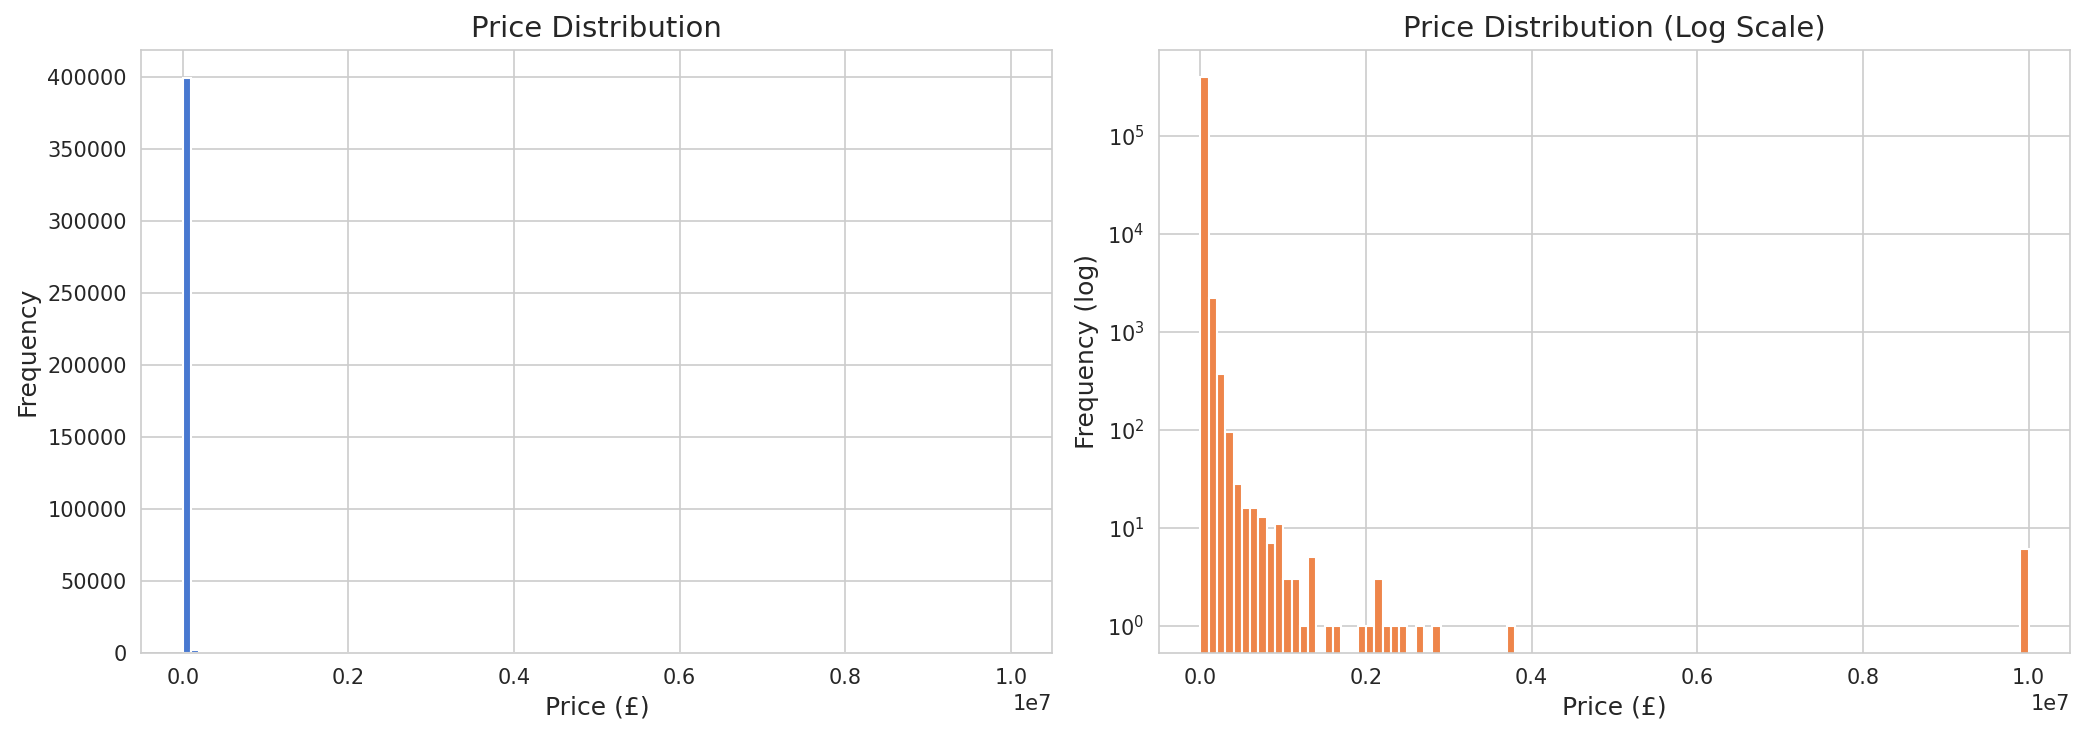


price summary statistics:
count    4.020050e+05
mean     1.734197e+04
std      4.643746e+04
min      1.200000e+02
25%      7.495000e+03
50%      1.260000e+04
75%      2.000000e+04
max      9.999999e+06

Skewness : 154.68
Kurtosis : 32182.67


In [8]:
# ------------------------------------------------------------
# 1.2  Price distribution — original & log scale
# ------------------------------------------------------------

# Identify the price column (common names in AutoTrader datasets)
price_col = None
for candidate in ["price", "Price", "selling_price", "price_in_pounds"]:
    if candidate in df.columns:
        price_col = candidate
        break

if price_col is None:
    # Fallback: pick the first column whose name contains "price"
    price_cols = [c for c in df.columns if "price" in c.lower()]
    if price_cols:
        price_col = price_cols[0]
    else:
        raise ValueError("Could not auto-detect a price column. Please set price_col manually.")

print(f"Using target column: '{price_col}'")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left — raw scale
axes[0].hist(df[price_col].dropna(), bins=100, color=sns.color_palette("muted")[0], edgecolor="white")
axes[0].set_title("Price Distribution")
axes[0].set_xlabel("Price (£)")
axes[0].set_ylabel("Frequency")

# Right — log scale
axes[1].hist(df[price_col].dropna(), bins=100, color=sns.color_palette("muted")[1], edgecolor="white", log=True)
axes[1].set_title("Price Distribution (Log Scale)")
axes[1].set_xlabel("Price (£)")
axes[1].set_ylabel("Frequency (log)")

plt.tight_layout()
# fig.savefig("figures/price_distribution.png")
plt.show()

# Summary stats for the target
print(f"\n{price_col} summary statistics:")
print(df[price_col].describe().to_string())
print(f"\nSkewness : {df[price_col].skew():.2f}")
print(f"Kurtosis : {df[price_col].kurtosis():.2f}")

### 1.3 Correlation Heatmap

The correlation matrix reveals linear relationships between numeric features. Strongly correlated feature pairs (|r| > 0.8) may introduce multicollinearity, while features with high absolute correlation to price are the most promising predictors.

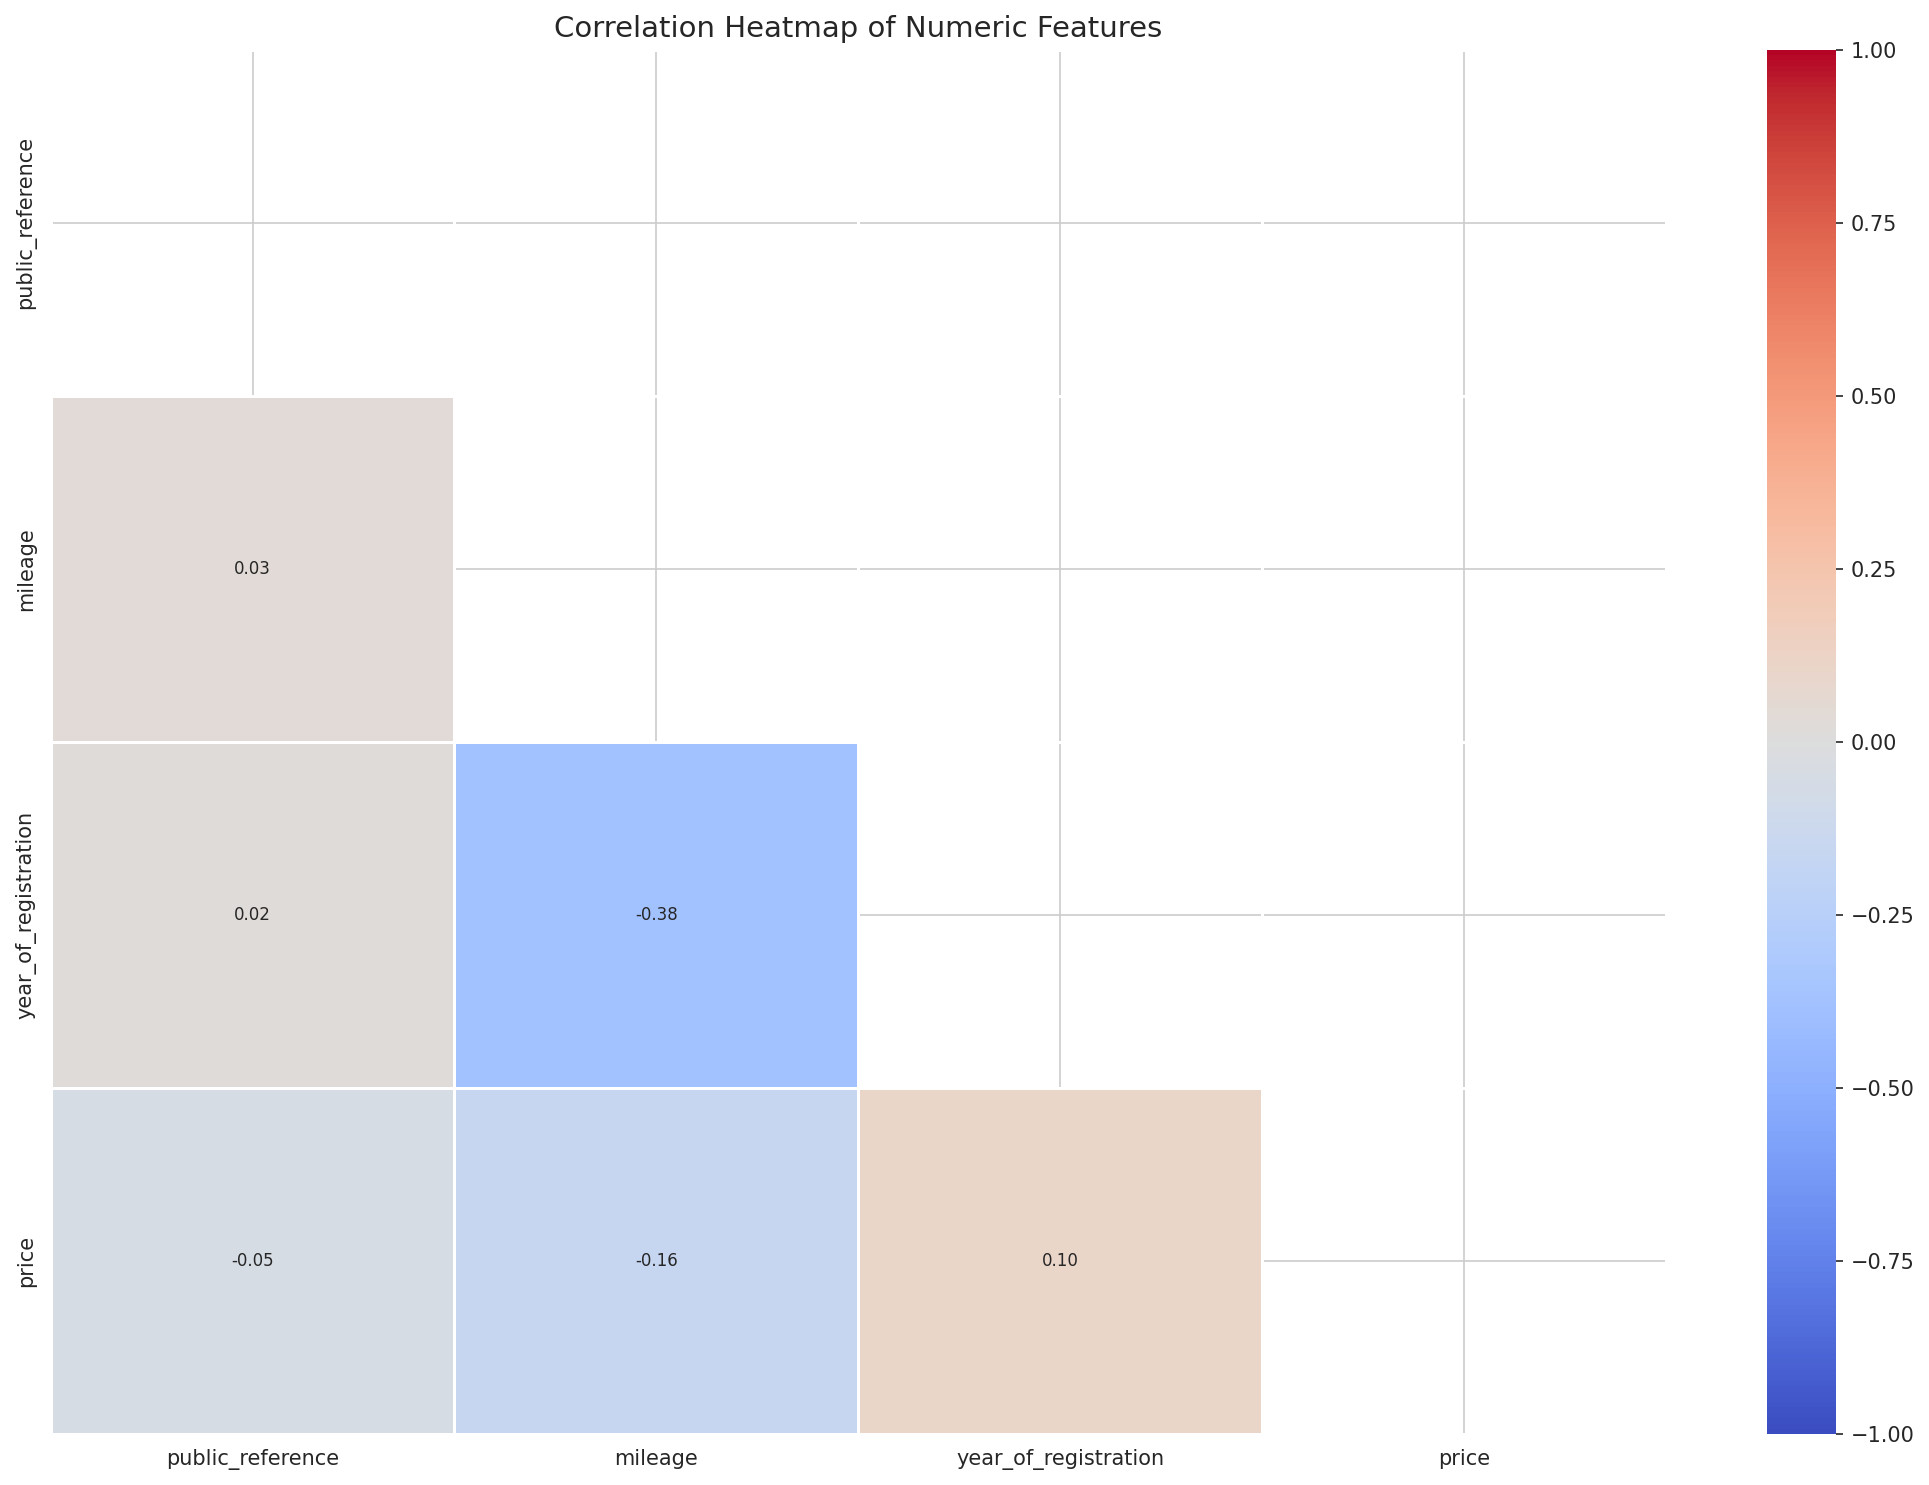

Top correlations with 'price':

mileage                 0.160204
year_of_registration    0.102341
public_reference        0.052344


In [9]:
# ------------------------------------------------------------
# 1.3  Correlation heatmap of numeric features
# ------------------------------------------------------------
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()

# Mask the upper triangle for cleaner visual
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    ax=ax,
    annot_kws={"size": 8},
    vmin=-1,
    vmax=1,
)
ax.set_title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
# fig.savefig("figures/correlation_heatmap.png")
plt.show()

# Print the features most correlated with price
if price_col in corr.columns:
    price_corr = corr[price_col].drop(price_col).abs().sort_values(ascending=False)
    print(f"Top correlations with '{price_col}':\n")
    print(price_corr.to_string())

### 1.4 Categorical Feature Cardinality

High-cardinality categorical features (e.g. specific model names) can cause dimensionality explosion with one-hot encoding. Identifying these early helps us decide between target encoding, frequency encoding, or grouping rare categories.

In [10]:
# ------------------------------------------------------------
# 1.4  Unique value counts for categorical columns
# ------------------------------------------------------------
cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

print(f"Categorical columns ({len(cat_cols)}):\n")
print(f"{'Column':<30} {'Unique Values':>15} {'Cardinality':<15}")
print("-" * 62)

cardinality = {}
for col in cat_cols:
    n_unique = df[col].nunique()
    cardinality[col] = n_unique
    label = "HIGH" if n_unique > 50 else ("MEDIUM" if n_unique > 10 else "LOW")
    print(f"{col:<30} {n_unique:>15,}  {label}")

# Flag high-cardinality features
high_card = {k: v for k, v in cardinality.items() if v > 50}
if high_card:
    print(f"\nHigh-cardinality features (>50 unique values): {list(high_card.keys())}")
    print("Consider target encoding or frequency encoding for these columns.")

# Show top 10 most frequent values for each categorical column
print(f"\n{'='*60}")
print("Top 10 values per categorical column:")
print(f"{'='*60}")
for col in cat_cols:
    print(f"\n{col}:")
    print(df[col].value_counts().head(10).to_string())

Categorical columns (7):

Column                           Unique Values Cardinality    
--------------------------------------------------------------
reg_code                                    72  HIGH
standard_colour                             22  MEDIUM
standard_make                              110  HIGH
standard_model                           1,168  HIGH
vehicle_condition                            2  LOW
body_type                                   16  MEDIUM
fuel_type                                    9  LOW

High-cardinality features (>50 unique values): ['reg_code', 'standard_make', 'standard_model']
Consider target encoding or frequency encoding for these columns.

Top 10 values per categorical column:

reg_code:
reg_code
17    36738
67    32230
66    25227
69    23825
18    21613
16    19998
19    18407
65    15635
68    15621
15    14010

standard_colour:
standard_colour
Black     86287
White     70535
Grey      68227
Blue      59784
Silver    49323
Red       42024
Gree

### 1.5 Drop High-Missingness and ID Columns

Columns with more than 60% missing data carry too little signal to be reliably imputed. We also drop identifier columns (`public_reference`, `reg_code`) that leak no predictive information. Following last semester's project, we engineer an `age` feature from `year_of_registration` before dropping it.

In [11]:
# ------------------------------------------------------------
# 1.5  Drop columns with >60% missing & ID/index columns
# ------------------------------------------------------------
print(f"Shape BEFORE cleaning: {df.shape}")
print(f"{'='*60}")

# --- a) Drop columns with >60% missing values ---
miss_pct = df.isnull().mean()
high_miss_cols = miss_pct[miss_pct > 0.60].index.tolist()
if high_miss_cols:
    print(f"Dropping columns with >60% missing: {high_miss_cols}")
    df.drop(columns=high_miss_cols, inplace=True)
else:
    print("No columns exceed 60% missingness.")

# --- b) Drop ID / index columns (no predictive value) ---
id_cols = [c for c in ["public_reference", "reg_code"] if c in df.columns]
if id_cols:
    print(f"Dropping ID columns: {id_cols}")
    df.drop(columns=id_cols, inplace=True)

# --- c) Feature-engineer 'age' from year_of_registration ---
if "year_of_registration" in df.columns:
    # New cars with missing year assumed to be current year (2023 data)
    df["year_of_registration"] = df["year_of_registration"].fillna(2023)
    df["age"] = 2023 - df["year_of_registration"]
    df.drop(columns=["year_of_registration"], inplace=True)
    print("Engineered 'age' from year_of_registration (missing → 2023).")

# --- d) Drop near-zero-variance boolean if present ---
if "crossover_car_and_van" in df.columns:
    pos_pct = df["crossover_car_and_van"].mean() * 100
    if pos_pct < 1.0:
        print(f"Dropping 'crossover_car_and_van' (only {pos_pct:.2f}% positive).")
        df.drop(columns=["crossover_car_and_van"], inplace=True)

print(f"\nShape AFTER dropping columns: {df.shape}")
print(f"Remaining columns: {df.columns.tolist()}")

Shape BEFORE cleaning: (402005, 12)
No columns exceed 60% missingness.
Dropping ID columns: ['public_reference', 'reg_code']
Engineered 'age' from year_of_registration (missing → 2023).
Dropping 'crossover_car_and_van' (only 0.45% positive).

Shape AFTER dropping columns: (402005, 9)
Remaining columns: ['mileage', 'standard_colour', 'standard_make', 'standard_model', 'vehicle_condition', 'price', 'body_type', 'fuel_type', 'age']


### 1.6 Impute Remaining Missing Values

Numeric columns are imputed with the median (robust to the skewed distributions we observed), while categorical columns are filled with their mode where one clear dominant value exists, or `"Unknown"` otherwise.

In [12]:
# ------------------------------------------------------------
# 1.6  Impute remaining missing values
# ------------------------------------------------------------
print(f"Missing values BEFORE imputation:\n{df.isnull().sum()[df.isnull().sum() > 0]}\n")

# Numeric columns → median
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if price_col in num_cols:
    num_cols.remove(price_col)  # don't impute the target

for col in num_cols:
    if df[col].isnull().any():
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f"  {col}: filled {df[col].isnull().sum()} NaNs with median = {median_val:.1f}")

# Categorical columns → mode (if dominant) or "Unknown"
cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
for col in cat_cols:
    if df[col].isnull().any():
        mode_val = df[col].mode()
        if len(mode_val) > 0:
            fill_val = mode_val[0]
        else:
            fill_val = "Unknown"
        n_missing = df[col].isnull().sum()
        df[col].fillna(fill_val, inplace=True)
        print(f"  {col}: filled {n_missing} NaNs with '{fill_val}'")

# Drop any rows still missing the target
before = len(df)
df.dropna(subset=[price_col], inplace=True)
dropped_target = before - len(df)
if dropped_target > 0:
    print(f"\nDropped {dropped_target} rows with missing target ({price_col}).")

print(f"\nRemaining missing values: {df.isnull().sum().sum()}")
print(f"Shape: {df.shape}")

Missing values BEFORE imputation:
mileage             127
standard_colour    5378
body_type           837
fuel_type           601
dtype: int64

  mileage: filled 0 NaNs with median = 28629.5
  standard_colour: filled 5378 NaNs with 'Black'
  body_type: filled 837 NaNs with 'Hatchback'
  fuel_type: filled 601 NaNs with 'Petrol'

Remaining missing values: 0
Shape: (402005, 9)


### 1.7 Outlier Handling

We apply domain-informed bounds: prices below £500 are likely listing errors, while prices above £150,000 represent a tiny fraction of ultra-luxury vehicles that would distort the model. Mileage is capped at 200,000 (beyond which listings are often commercial vehicles or data errors) and age at 30 years to exclude vintage/classic cars that follow different pricing dynamics.

In [13]:
# ------------------------------------------------------------
# 1.7  Outlier removal — domain-informed bounds
# ------------------------------------------------------------
n_before = len(df)

# Price bounds
PRICE_MIN = 500
PRICE_MAX = 150_000
df = df[(df[price_col] >= PRICE_MIN) & (df[price_col] <= PRICE_MAX)].copy()
print(f"Price filter (£{PRICE_MIN:,}–£{PRICE_MAX:,}): "
      f"removed {n_before - len(df):,} rows ({(n_before - len(df))/n_before*100:.2f}%)")

# Mileage cap
MILEAGE_CAP = 200_000
if "mileage" in df.columns:
    n_tmp = len(df)
    df = df[df["mileage"] <= MILEAGE_CAP].copy()
    print(f"Mileage cap (≤{MILEAGE_CAP:,}): removed {n_tmp - len(df):,} rows")

# Age cap
AGE_CAP = 30
if "age" in df.columns:
    n_tmp = len(df)
    df = df[df["age"] <= AGE_CAP].copy()
    print(f"Age cap (≤{AGE_CAP} years): removed {n_tmp - len(df):,} rows")

print(f"\nShape AFTER outlier removal: {df.shape}  "
      f"(total removed: {n_before - len(df):,} = {(n_before - len(df))/n_before*100:.1f}%)")

Price filter (£500–£150,000): removed 1,572 rows (0.39%)
Mileage cap (≤200,000): removed 333 rows
Age cap (≤30 years): removed 852 rows

Shape AFTER outlier removal: (399248, 9)  (total removed: 2,757 = 0.7%)


### 1.8 Feature Engineering: Brand Prestige

Reusing the domain-knowledge-driven prestige classification from last semester. This groups ~70+ car makes into 5 tiers based on typical market positioning, providing a powerful ordinal feature that captures the strong relationship between brand and price.

In [14]:
# ------------------------------------------------------------
# 1.8  Brand prestige classification (from last semester)
# ------------------------------------------------------------

# Define prestige levels with numbers as keys and lists of brands as values
PRESTIGE_LEVEL_BRANDS = {
    5: ['Ferrari', 'Lamborghini', 'McLaren', 'Bugatti', 'Pagani'],
    4: ['Bentley', 'Rolls-Royce', 'Maybach', 'Daimler', 'BAC'],
    3: ['Jaguar', 'Land Rover', 'Porsche', 'Maserati', 'Aston Martin', 'Lotus', 'TVR',
        'Morgan', 'Caterham', 'Noble', 'Ariel', 'Alpine', 'Corvette', 'Hummer', 'Radical',
        'Ultima', 'AC', 'Bristol', 'Jensen', 'Triumph'],
    2: ['Audi', 'BMW', 'Mercedes-Benz', 'Volkswagen', 'MINI', 'Volvo', 'Lexus',
        'Alfa Romeo', 'Subaru', 'Infiniti', 'Tesla', 'Abarth', 'Cadillac', 'Lincoln',
        'Saab', 'Lancia', 'Chrysler', 'Buick', 'Westfield', 'Zenos'],
    1: [ # Budget + Mass Market brands
        'Dacia', 'Perodua', 'Proton', 'SsangYong', 'Daewoo', 'Great Wall', 'Rover',
        'MG', 'Suzuki', 'Daihatsu', 'Datsun', 'Aixam', 'Reliant',
        'Vauxhall', 'SKODA', 'SEAT', 'Peugeot', 'Citroen', 'Renault', 'Fiat', 'Kia',
        'Hyundai', 'Nissan', 'Toyota', 'Honda', 'Mazda', 'Mitsubishi', 'Ford',
        'Chevrolet', 'Opel', 'Smart', 'DS AUTOMOBILES', 'CUPRA', 'Jeep', 'Dodge',
        'GMC', 'Isuzu', 'Pontiac', 'Plymouth', 'Holden', 'International',
        'London Taxis International', 'LEVC', 'Carbodies', 'Iveco',
        'Panther', 'Replica', 'Custom Vehicle', 'Dax', 'Tiger', 'Pilgrim', 'Mev',
        'Beauford', 'Sebring', 'Gentry', 'AK', 'Mitsuoka', 'Austin', 'Morris',
        'Leyland', 'Wolseley'
    ]
}

# Flatten the PRESTIGE_LEVEL_BRANDS into a brand-to-prestige-level map
# This is done for efficient lookup in the get_brand_prestige_class function
prestige_map = {}
for level, brands in PRESTIGE_LEVEL_BRANDS.items():
    for brand in brands:
        prestige_map[brand] = level

def get_brand_prestige_class(brand):
    return prestige_map.get(brand, 2)  # default to economy if unknown


if "standard_make" in df.columns:
    df["brand_prestige"] = df["standard_make"].apply(get_brand_prestige_class)
    print("Brand prestige distribution:")
    print(df.groupby("brand_prestige")[price_col].agg(["count", "mean", "median"]).round(0))
    print(f"\nNew column 'brand_prestige' added (1=Budget → 5=Exotic).")

Brand prestige distribution:
                 count      mean   median
brand_prestige                           
1               200915   10960.0   9500.0
2               168971   18914.0  15990.0
3                27586   35965.0  29995.0
4                 1046   67842.0  59997.0
5                  730  104755.0  99995.0

New column 'brand_prestige' added (1=Budget → 5=Exotic).


### 1.9 Reduce High-Cardinality Categoricals

For columns like `standard_make`, `standard_colour`, and `body_type`, we keep only the most frequent values and bucket everything else as `"Other"`. This prevents rare categories (with very few samples) from creating noisy, unreliable encoded features.

In [15]:
# ------------------------------------------------------------
# 1.9  Bucket rare categories → "Other"
# ------------------------------------------------------------
def bucket_rare(df, column, top_n):
    """Keep top_n most frequent values, bucket the rest as 'Other'."""
    if column not in df.columns:
        return
    top = df[column].value_counts().nlargest(top_n).index
    before_unique = df[column].nunique()
    df[column] = df[column].where(df[column].isin(top), other="Other")
    print(f"  {column}: {before_unique} → {df[column].nunique()} categories (top {top_n} + Other)")

bucket_rare(df, "standard_make",   top_n=20)
bucket_rare(df, "standard_colour", top_n=10)
bucket_rare(df, "body_type",       top_n=8)
bucket_rare(df, "fuel_type",       top_n=4)

# If standard_model survived earlier cleaning
bucket_rare(df, "standard_model",  top_n=20)

# Verify
cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
print(f"\nCategorical columns after bucketing: {cat_cols}")
for col in cat_cols:
    print(f"  {col}: {df[col].nunique()} unique values")

  standard_make: 98 → 21 categories (top 20 + Other)
  standard_colour: 22 → 11 categories (top 10 + Other)
  body_type: 16 → 9 categories (top 8 + Other)
  fuel_type: 9 → 5 categories (top 4 + Other)
  standard_model: 1032 → 21 categories (top 20 + Other)

Categorical columns after bucketing: ['standard_colour', 'standard_make', 'standard_model', 'vehicle_condition', 'body_type', 'fuel_type']
  standard_colour: 11 unique values
  standard_make: 21 unique values
  standard_model: 21 unique values
  vehicle_condition: 2 unique values
  body_type: 9 unique values
  fuel_type: 5 unique values


### 1.10 Encode Categorical Features

We use a mixed encoding strategy:
- **Ordinal encoding** for `fuel_type` and `vehicle_condition` which have a natural ordering (e.g. petrol < hybrid < electric; used < nearly-new < new).
- **Frequency encoding** for high-cardinality columns like `standard_make` — this preserves information about how common a category is without creating hundreds of dummy columns. We also apply it to `standard_colour`, `body_type`, and `standard_model` if present.

In [16]:
# ------------------------------------------------------------
# 1.10  Encode categorical features
# ------------------------------------------------------------

# --- a) Ordinal encoding for features with natural ordering ---
fuel_order = {
    "Petrol": 0, "Diesel": 1, "Hybrid – Petrol/Electric": 2,
    "Hybrid – Diesel/Electric": 3, "Electric": 4, "Other": 5, "Unknown": 5
}
condition_order = {"USED": 0, "NEARLY NEW": 1, "NEW": 2, "Unknown": 0, "Other": 0}

if "fuel_type" in df.columns:
    df["fuel_type_enc"] = df["fuel_type"].map(fuel_order).fillna(5).astype(int)
    print(f"fuel_type → ordinal encoded (0–5)")
    df.drop(columns=["fuel_type"], inplace=True)

if "vehicle_condition" in df.columns:
    df["vehicle_condition_enc"] = (
        df["vehicle_condition"].str.upper().map(condition_order).fillna(0).astype(int)
    )
    print(f"vehicle_condition → ordinal encoded (0–2)")
    df.drop(columns=["vehicle_condition"], inplace=True)

# --- b) Frequency encoding for remaining categoricals ---
freq_encode_cols = [c for c in df.select_dtypes(include=["object", "category"]).columns]
print(f"\nFrequency-encoding: {freq_encode_cols}")

freq_maps = {}
for col in freq_encode_cols:
    freq = df[col].value_counts(normalize=True)
    freq_maps[col] = freq.to_dict()
    df[f"{col}_freq"] = df[col].map(freq).astype(float)
    df.drop(columns=[col], inplace=True)
    print(f"  {col} → {col}_freq  (range: {df[f'{col}_freq'].min():.4f} – {df[f'{col}_freq'].max():.4f})")

print(f"\nAll categoricals encoded. Remaining dtypes:")
print(df.dtypes.value_counts())

fuel_type → ordinal encoded (0–5)
vehicle_condition → ordinal encoded (0–2)

Frequency-encoding: ['standard_colour', 'standard_make', 'standard_model', 'body_type']
  standard_colour → standard_colour_freq  (range: 0.0050 – 0.2279)
  standard_make → standard_make_freq  (range: 0.0187 – 0.1045)
  standard_model → standard_model_freq  (range: 0.0092 – 0.6726)
  body_type → body_type_freq  (range: 0.0015 – 0.4201)

All categoricals encoded. Remaining dtypes:
float64    6
int64      4
Name: count, dtype: int64


### 1.11 Feature Scaling & Train/Test Split

We standardise all numeric features to zero mean and unit variance using `StandardScaler`, fitting on the training set only to avoid data leakage. The target is log-transformed (`log1p`) to reduce skewness, following the approach from last semester. The scaler object is saved for reuse during inference.

In [17]:
# ------------------------------------------------------------
# 1.11  Train/test split + StandardScaler (fit on train only)
# ------------------------------------------------------------

# Log-transform the target (reduces right-skew)
y = np.log1p(df[price_col])
X = df.drop(columns=[price_col])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED
)
print(f"Train set: {X_train.shape}   Test set: {X_test.shape}")

# Fit scaler on training data only, then transform both
scaler = StandardScaler()
feature_names = X_train.columns.tolist()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train), columns=feature_names, index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test), columns=feature_names, index=X_test.index
)

print(f"\nScaler fitted on {len(feature_names)} features (saved as 'scaler').")
print(f"Training features — mean ≈ 0: {X_train_scaled.mean().abs().max():.6f}, "
      f"std ≈ 1: {X_train_scaled.std().mean():.4f}")

Train set: (319398, 9)   Test set: (79850, 9)

Scaler fitted on 9 features (saved as 'scaler').
Training features — mean ≈ 0: 0.000000, std ≈ 1: 1.0000


### 1.12 Final Feature Set Summary

A compact overview of every feature entering the model — its data type, range, and a sample of values. This serves as a reference for all subsequent sections.

In [18]:
# ------------------------------------------------------------
# 1.12  Summary table of final feature set
# ------------------------------------------------------------
summary_rows = []
for col in X_train_scaled.columns:
    raw = X_train[col]  # unscaled for interpretable stats
    summary_rows.append({
        "Feature": col,
        "Dtype": str(raw.dtype),
        "Min": f"{raw.min():.2f}",
        "Median": f"{raw.median():.2f}",
        "Max": f"{raw.max():.2f}",
        "Sample Values": str(raw.dropna().sample(3, random_state=SEED).values.tolist()),
    })

summary_df = pd.DataFrame(summary_rows)
print(f"Final feature set: {len(summary_df)} features")
print(f"Training samples : {len(X_train_scaled):,}")
print(f"Test samples     : {len(X_test_scaled):,}")
print(f"Target           : log1p({price_col})\n")
summary_df

Final feature set: 9 features
Training samples : 319,398
Test samples     : 79,850
Target           : log1p(price)



,Feature,Dtype,Min,Median,Max,Sample Values
0,mileage,float64,0.00,28692.00,200000.00,"[10.0, 57000.0, 125300.0]"
1,age,float64,0.00,6.00,30.00,"[0.0, 9.0, 12.0]"
2,brand_prestige,int64,1.00,1.00,5.00,"[1, 2, 2]"
3,fuel_type_enc,int64,0.00,0.00,5.00,"[0, 1, 1]"
4,vehicle_condition_enc,int64,0.00,0.00,2.00,"[2, 0, 0]"
5,standard_colour_freq,float64,0.01,0.17,0.23,"[0.01014908027090931, 0.1488122670620767, 0.12..."
6,standard_make_freq,float64,0.02,0.08,0.10,"[0.08423586342323568, 0.02868643048931992, 0.0..."
7,standard_model_freq,float64,0.01,0.67,0.67,"[0.026612531559331545, 0.6726470765038272, 0.0..."
8,body_type_freq,float64,0.00,0.29,0.42,"[0.42010980643609985, 0.42010980643609985, 0.0..."


---
## 2. Automated Feature Selection

---
## 3. Tree Ensembles

---
## 4. Ensemble of Tree Ensembles

---
## 5. Feature Importance

---
## 6. SHAP/PDP Model Explanations

---
## 7. Dimensionality Reduction (Linear)

---
## 8. Dimensionality Reduction (Non-Linear)

---
## 9. Polynomial Regression

---
## 10. Clustering for Feature Engineering